# Filter the density field of an Arepo simulation

In this notebook we show how to use the `SmoothingFilter` class to filter the density field of an Arepo simulation, obtainig the smooth field $\langle \rho \rangle$ and the fluctuating component $\delta \rho = \rho - \langle \rho \rangle$.

In [18]:
import paicos as pa
import numpy as np
import turbocluster as tc

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, SymLogNorm
import matplotlib as mpl

pa.settings.strict_units = False
# A snapshot object
snap = pa.Snapshot(pa.data_dir, 247)

center = snap.Cat.Group['GroupPos'][0]
widths = np.array([3e3, 3e3, 3e3], dtype=float)

threadsperblock = 64


Two smoothing kernels are implemented in Turbocluster: the 'mean' (spherical top-hat) and the 'gaussian' kernel. Moreover the convolution integral can optionally be weighted by a function (be it mass, emissivity, etc.)

In this notebook we use a filter length of 500 arepo_units to make up for the very coarse resolution. Note however that the computational cost will increase as $\sim \ell^3$.

In [2]:
weight=None
# filter_type = 'gaussian'
filter_type = 'mean'
arepo_length = snap.length.uq
filter_length = 500*arepo_length

We can also give an `Orientation` object to the `SmoothingFilter`, defined by a normal vector and a perpendicular vector

In [3]:
orientation = pa.Orientation(normal_vector=[1,-2,1], 
                            perp_vector1=[0,0.2,-0.3])

In [4]:

sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=orientation, threadsperblock=threadsperblock)

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


The filtered (i.e. smooth) variable can be easily obtained by calling the `filter_variable` method. 

In [5]:
smooth_den = sf.filter_variable(
        '0_Density',
        filter_length,
        weight=weight,
        filter_type=filter_type
    )

Note however that the final filtered field only has the mesh points that belong to the cubic region defined by `widths` and `center`.

In [6]:
smooth_den.shape, snap['0_Density'].shape

((55867,), (2172897,))

Turbocluster offers a convenience function that returns the filtered and turbulent components as arrays that have the same shape as the original data array, but with zeros outside the cubic region defined by `widths` and `center`. This is useful because the filtered and turbulent fields can be given to Paicos for further processing, e.g., to take slices or make projections.

In [7]:
from turbocluster.helper_functions import extract_turbulent_var

In [8]:
smooth_den, turb_den = extract_turbulent_var(snap, sf, '0_Density', 
                                            filter_length=filter_length, 
                                            weight=weight, filter_type=filter_type)

min/max/avg occupancy cartesian tiling 0 / 182 / 436.46


In [9]:
widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, orientation, npix=2048)
extent = slicer.centered_extent.to('Mpc')

In [10]:
dens_tot = slicer.slice_variable('0_Density')
dens_bulk = slicer.slice_variable(smooth_den)
dens_turb = slicer.slice_variable(turb_den)

Now we plot the results! Note that the sample grid is very coarse here, therefore the filtered data will not look very nice.

Text(0.5, 0.95, 'Density field after filtering: bulk and turbulent components')

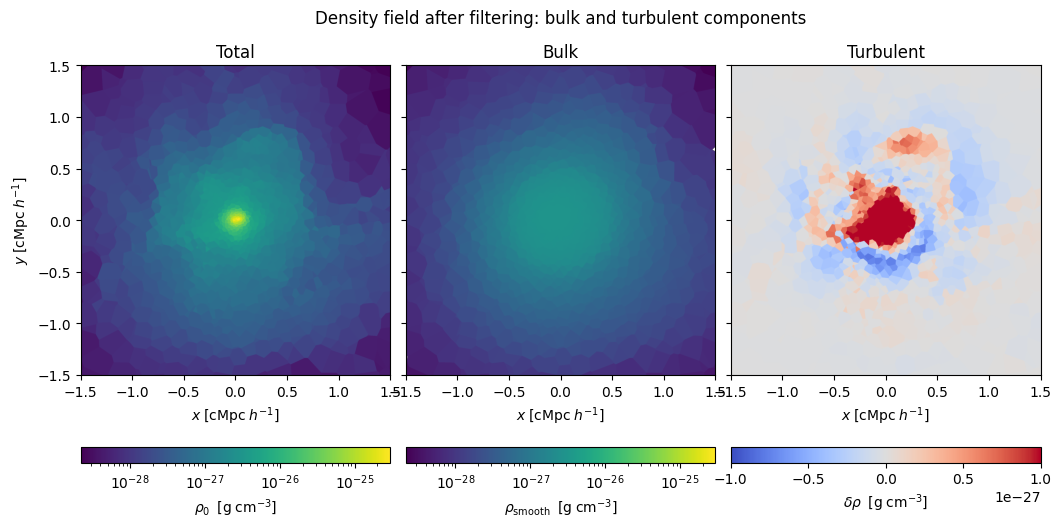

In [22]:

dens_tot = dens_tot.to_physical.cgs
dens_bulk = dens_bulk.to_physical.cgs
dens_turb = dens_turb.to_physical.cgs

vmin = dens_tot.value.min()
vmax = dens_tot.value.max()
norm = LogNorm(vmin=vmin,vmax=vmax)

# vmax = 0.8*dens_turb.value.max()
vmax = 1e-27
vmin = -vmax
norm1 = Normalize(vmin=vmin,vmax=vmax)
cmap = mpl.colormaps['coolwarm']

fig, axes = plt.subplots(1,3, figsize=(12,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_tot.value, origin='lower', norm=norm,extent=extent.value)
im2 = axes[1].imshow(
    dens_bulk.value, origin='lower', norm=norm,extent=extent.value)
im3 = axes[2].imshow(
    dens_turb.value, origin='lower', norm=norm1,cmap=cmap,extent=extent.value)

axes[0].set_title('Total')
axes[1].set_title('Bulk')
axes[2].set_title('Turbulent')

for i in range(3):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_0'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_{\\mathrm{smooth}}'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(dens_tot.label('\\delta \\rho '))



fig.subplots_adjust(top=0.9,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field after filtering: bulk and turbulent components',y=0.95)
